In [3]:
import plotly.express as px
import plotly.offline as pyo

In [4]:
import pandas as pd
df = pd.read_csv('/content/gdp.csv')
df.head(10)

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10
5,Arab World,ARB,1973,5.501839e+10
6,Arab World,ARB,1974,1.051458e+11
7,Arab World,ARB,1975,1.163370e+11
8,Arab World,ARB,1976,1.448462e+11
9,Arab World,ARB,1977,1.673083e+11


In [5]:
df.shape

(11507, 4)

In [6]:
df['Country Name'].nunique()

256

In [7]:
df['Country Code'].nunique()

256

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11507 entries, 0 to 11506
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  11507 non-null  object 
 1   Country Code  11507 non-null  object 
 2   Year          11507 non-null  int64  
 3   Value         11507 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 359.7+ KB


In [9]:
df.isnull().sum()

,0
Country Name,0
Country Code,0
Year,0
Value,0


**Checking Description of each Column**

In [10]:
df['Country Name'].describe()

,Country Name
count,11507
unique,256
top,Caribbean small states
freq,57


In [11]:
df['Country Code'].describe()

,Country Code
count,11507
unique,256
top,CSS
freq,57


In [12]:
df['Year'].describe()

,Year
count,11507.000000
mean,1991.265230
std,15.886648
min,1960.000000
25%,1978.000000
50%,1993.000000
75%,2005.000000
max,2016.000000


In [13]:
df['Value'].describe()

,Value
count,1.150700e+04
mean,1.005972e+12
std,4.533056e+12
min,8.824448e+06
25%,2.056874e+09
50%,1.436880e+10
75%,1.796394e+11
max,7.904923e+13


**Analysing Arab World**

In [25]:
df_pr = df[df['Country Name'] == 'Arab World']

<Axes: xlabel='Year', ylabel='GDP'>

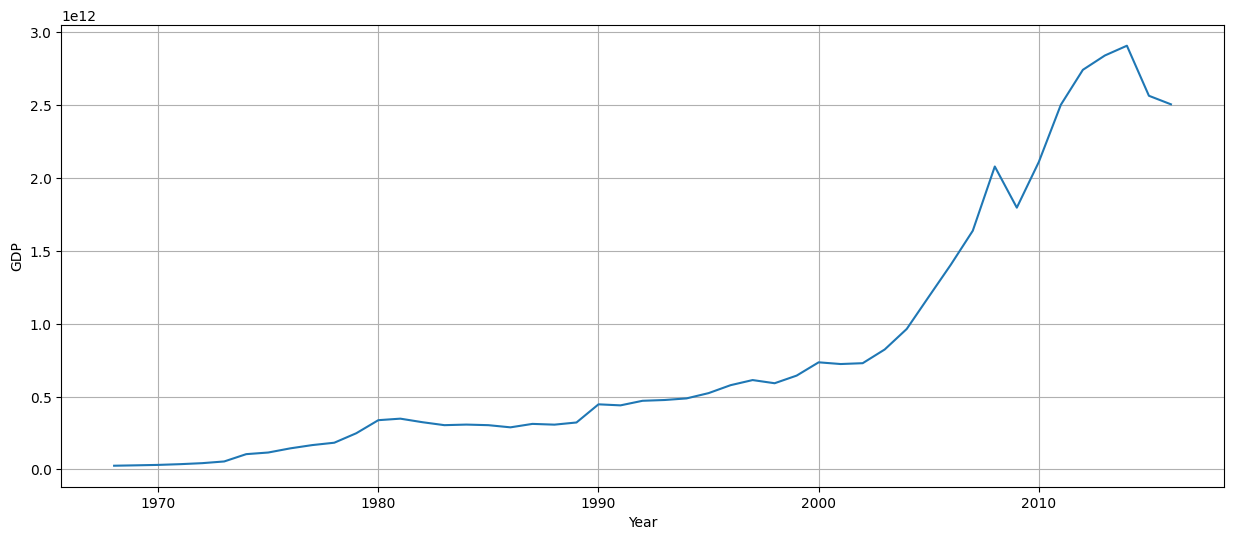

In [26]:
df_pr.plot(kind= 'line', x= 'Year', y = 'Value', figsize=(15,6), legend= False, grid= True, ylabel= 'GDP')

**Finding GDP of a Country**

In [27]:
df_pr = df[df['Country Name'] == 'Arab World']

data = df_pr.values

gdp_change = [0]

for i in range(1,len(data)):

    prev = data[i-1][3]
    cur = data[i][3]

    gdp_change.append(round(((cur - prev) / prev)*100,2))

df_pr = df_pr.assign(GDP = gdp_change)

**Finding GDP of Every Country**

In [28]:
final_data = []

for country_name in df['Country Name'].unique():

    df_pr = df[df['Country Name'] == country_name]

    data = df_pr.values
    gdp_change = [0]

    for i in range(1,len(data)):

        prev = data[i-1][3]
        cur = data[i][3]

        gdp_change.append(round(((cur - prev) / prev)*100,2))

    df_pr = df_pr.assign(GDP = gdp_change)
    final_data.append(df_pr)

In [29]:
df = pd.concat(final_data, axis = 0)

In [30]:
df.head()

,Country Name,Country Code,Year,Value,GDP
0,Arab World,ARB,1968,2.576068e+10,0.00
1,Arab World,ARB,1969,2.843420e+10,10.38
2,Arab World,ARB,1970,3.138550e+10,10.38
3,Arab World,ARB,1971,3.642691e+10,16.06
4,Arab World,ARB,1972,4.331606e+10,18.91


In [20]:
df.groupby('Country Name')['GDP'].mean().sort_values(ascending= False)

,GDP
Country Name,
Cayman Islands,108.380000
Equatorial Guinea,22.312453
Nauru,20.650000
Iraq,18.075854
Oman,17.681154
...,...
Barbados,3.109259
San Marino,2.148333
American Samoa,1.937333


In [21]:
df.groupby('Country Name')['Value'].max().sort_values(ascending= False).head(20)

,Value
Country Name,
World,7.904923e+13
High income,5.036240e+13
OECD members,4.937008e+13
Post-demographic dividend,4.673504e+13
IDA & IBRD total,2.948247e+13
Low & middle income,2.870476e+13
Middle income,2.829277e+13
IBRD only,2.739661e+13
Europe & Central Asia,2.365470e+13


In [22]:
df_pr = df[df['Country Name'] == 'World']

fig=px.line(df_pr, x='Year', y='Value', title='GDP of World')

fig

In [23]:
pyo.plot(fig, filename= 'world gdp.html')

'world gdp.html'

In [24]:
df_pr = df[df['Country Name'] == 'India']

fig=px.line(df_pr, x='Year', y='Value', title='GDP of India')

fig

**GDP of each country**

In [33]:
import os

In [34]:
os.mkdir('GDP Individual')

for country_name in df['Country Name'].unique():

    df_pr = df[df['Country Name'] == country_name]

    fig=px.line(df_pr, x='Year', y='Value', title=f'GDP of {country_name}')

    pyo.plot(fig, filename= 'GDP Individual/' + f'{country_name}.html', auto_open = False)


In [ ]:
os.mkdir('GDP Individual WRT World')

for country_name in df['Country Name'].unique():

    df_pr = df[df['Country Name'] == country_name]

    fig=px.line(df_pr, x='Year', y='Value', title=f'GDP of {country_name}', range_y = (0,80000000000000))

    pyo.plot(fig, filename= 'GDP Individual WRT World/' + f'{country_name}.html', auto_open = False)

**GDP of all the Countries**

In [36]:
fig=px.line(df, x='Year', y='Value', title='GDP Analysis of all countries', color = 'Country Name')

pyo.plot(fig, filename= 'CountriesGDP.html')

'CountriesGDP.html'